# Metient-evaluate

##### This tutorial is intended for those who want to run Metient in evaluate mode, where they already have the observed clone percentages and wish to label the clone tree. 

##### To run this notebook, you'll need metient installed (follow installation instructions on the github README)

### Import libraries and setup paths

In [1]:
import os
import metient as met
import warnings
warnings.filterwarnings('ignore')

### Setup paths
# Path to where our input clone trees and tsvs are located
notebook_dir = '/lila/data/morrisq/divyak/projects/metient/tutorial'
input_dir = os.path.join(notebook_dir, "inputs")
# Path to save outputs
output_dir = os.path.join(notebook_dir,  "4_outputs")

### An example of the expected tsv file format for NSCLC patient CRUK0010
**The required columns are:**
`anatomical_site_index, anatomical_site_label, cluster_index, cluster_label, present, site_category, num_mutations` (see `../README.md` for description of each column)

In [2]:
import pandas as pd
df = pd.read_csv(os.path.join(input_dir, "CRUK0010_SNVs.tsv"), sep="\t")
df

,anatomical_site_index,anatomical_site_label,cluster_index,cluster_label,present,site_category,num_mutations
0,0,primary_SU_T1,0,SPTAN1;SETD2,0,primary,58
1,1,LN_SU_FLN1,0,SPTAN1;SETD2,0,metastasis,58
2,2,metachronousMet_BR_LN1,0,SPTAN1;SETD2,0,metastasis,58
3,3,metachronousMet_BR_LN2,0,SPTAN1;SETD2,0,metastasis,58
4,4,metachronousMet_BR_LN3,0,SPTAN1;SETD2,0,metastasis,58
...,...,...,...,...,...,...,...
70,0,primary_SU_T1,14,OTUD7B;BVES-AS1,0,primary,5
71,1,LN_SU_FLN1,14,OTUD7B;BVES-AS1,0,metastasis,5
72,2,metachronousMet_BR_LN1,14,OTUD7B;BVES-AS1,0,metastasis,5
73,3,metachronousMet_BR_LN2,14,OTUD7B;BVES-AS1,0,metastasis,5


## Step 1: Run Metient-evaluate on each patient individually

/lila/data/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0003_SNVs.tsv
O: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1']
Input tree has 16 nodes, calculated sample size: 2304
input_T.shape torch.Size([16, 16])
Using sparse T: False


100%|█████████▉| 2788/2800 [00:26<00:00, 120.73it/s]

Number of final solutions: 1
CRUK0003_primary_SU_T1


<Figure size 640x480 with 0 Axes>

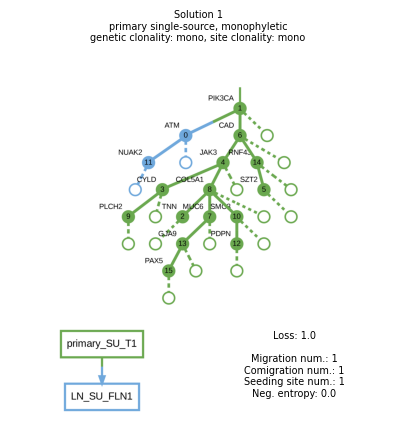

/lila/data/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0010_SNVs.tsv
O: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1', 'metachronousMet_BR_LN1', 'metachronousMet_BR_LN2', 'metachronousMet_BR_LN3']
Input tree has 15 nodes, calculated sample size: 2648
input_T.shape torch.Size([15, 15])
Using sparse T: False


100%|█████████▉| 2792/2800 [00:26<00:00, 103.02it/s]

Number of final solutions: 1
CRUK0010_primary_SU_T1


<Figure size 640x480 with 0 Axes>

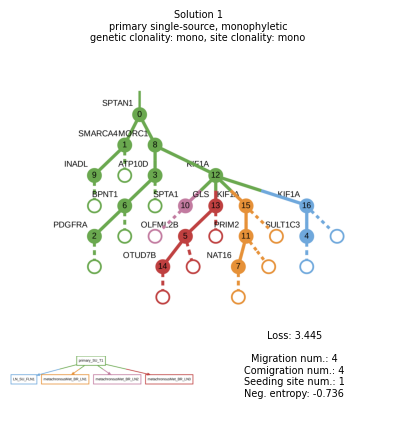

/lila/data/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0013_SNVs.tsv
O: None
Tumor samples: ['LN_SU_LN1', 'LN_SU_LN2', 'primary_SU_T1', 'LN_SU_FLN1', 'LN_SU_FLN2']
Input tree has 7 nodes, calculated sample size: 2328
input_T.shape torch.Size([7, 7])
Using sparse T: False


100%|█████████▉| 2792/2800 [00:26<00:00, 147.75it/s]

Number of final solutions: 2
CRUK0013_primary_SU_T1


<Figure size 640x480 with 0 Axes>

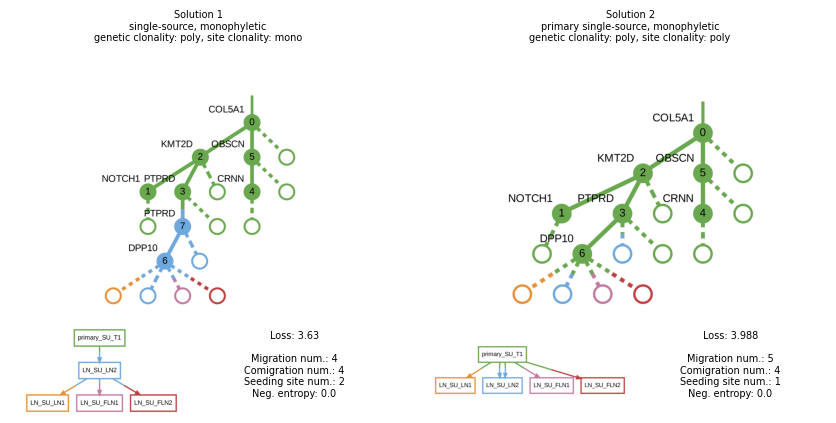

/lila/data/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0029_SNVs.tsv
O: None
Tumor samples: ['LN_SU_LN5', 'LN_SU_LN7', 'primary_SU_T1', 'LN_SU_FLN1', 'metachronousMet_BR_T1']
Input tree has 15 nodes, calculated sample size: 2648
input_T.shape torch.Size([15, 15])
Using sparse T: False


100%|█████████▉| 2793/2800 [00:35<00:00, 96.02it/s]

Number of final solutions: 2
CRUK0029_primary_SU_T1


<Figure size 640x480 with 0 Axes>

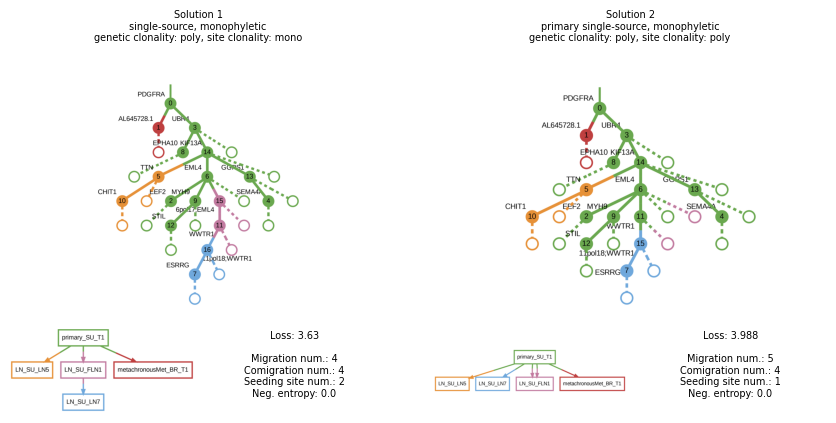

/lila/data/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0590_SNVs.tsv
O: None
Tumor samples: ['primary_SU_T1', 'metachronousMet_BR_T1.FR2', 'metachronousMet_BR_T1.FR1', 'metachronousMet_BR_T3.FR1', 'LN_SU_FLN1']
Input tree has 19 nodes, calculated sample size: 2808
input_T.shape torch.Size([19, 19])
Using sparse T: False


100%|██████████| 2800/2800 [00:30<00:00, 83.55it/s] 

Number of final solutions: 2
CRUK0590_primary_SU_T1


<Figure size 640x480 with 0 Axes>

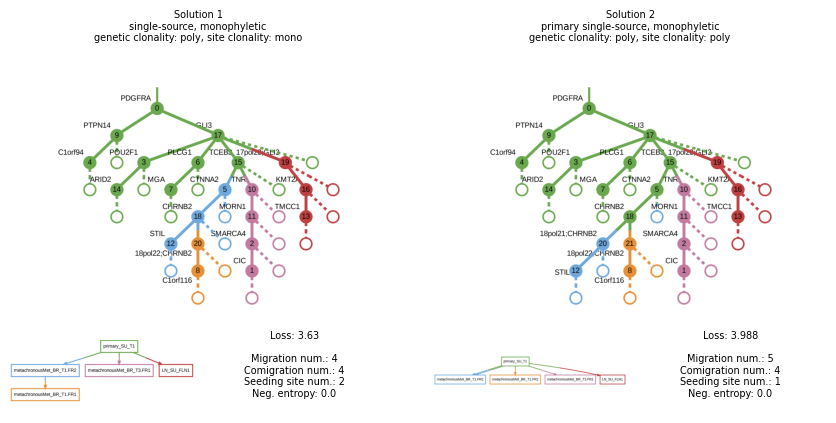

In [3]:
patients = ["CRUK0003", "CRUK0010", "CRUK0013", "CRUK0029", "CRUK0590"]

print_config = met.PrintConfig(visualize=True, verbose=False, k_best_trees=5)
# Use weights which have been calibrated to real data
weights = met.Weights.pancancer_genetic_organotropism_uniform_weighting()

for patient in patients:
    clone_tree_fn = os.path.join(input_dir, f"{patient}_tree.txt")
    ref_var_fn = os.path.join(input_dir, f"{patient}_SNVs.tsv")
    met.evaluate_label_clone_tree(clone_tree_fn, ref_var_fn, weights, print_config, 
                                  output_dir, patient, solve_polytomies=True)


## Step 3: Use the pickle file outputs for downstream analysis

### In addition to the visualizations that Metient provides, we also save pkl.gz files for each Metient run that contain all the results of the run.

In [4]:
import gzip
import pickle

with gzip.open(os.path.join(output_dir, "CRUK0590_primary_SU_T1.pkl.gz") ,"rb") as f:
    pckl = pickle.load(f)
print(pckl.keys())

BEST_TREE_IDX = 0
# V is the best node labeling
V = pckl['node_labels'][BEST_TREE_IDX]
# A is the adjacency matrix that is the input clone tree + inferred leaf nodes + polytomy resolution
parents = pckl['parents'][BEST_TREE_IDX]
A = met.adjacency_matrix_from_parents(parents)
print(A.shape)
# G represents the migration graph
G = met.migration_graph(V, A)
print("\nmigration graph:\n", G)

node_info = pckl['node_info'][BEST_TREE_IDX]

# Show other information about this patient's inferred migration history
print("\nseeding pattern:", met.seeding_pattern(V, A))
print("seeding clusters:", met.seeding_clusters(V, A,node_info))
print("phyleticity:", met.phyleticity(V, A, node_info))
print("site clonality:", met.site_clonality(V, A))
print("genetic clonality:", met.genetic_clonality(V, A,node_info))

dict_keys(['node_labels', 'losses', 'node_info', 'parents', 'anatomical_sites', 'loss_info', 'primary_site', 'soft_labeling', 'genetic_distances', 'observed_proportions'])
torch.Size([41, 41])

migration graph:
 tensor([[0., 1., 0., 1., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

seeding pattern: single-source
seeding clusters: [17, 10, 18, 5]
phyleticity: monophyletic
site clonality: monoclonal
genetic clonality: polyclonal
